In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
Titanic= pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\Titanic-Dataset.csv")
sns.set_theme(style='whitegrid', palette='muted')
BLUE, ORANGE, GREEN, RED = '#2563EB', '#F97316', '#16A34A', '#DC2626'
PURPLE, TEAL = '#7C3AED', '#0891B2'
colors = [BLUE, ORANGE, GREEN, RED, PURPLE, TEAL]
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
#Understanding the data
Titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
Titanic.shape

(891, 12)

In [4]:
Titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [6]:
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
duplicates = Titanic.duplicated().sum()
duplicates

np.int64(0)

In [8]:
Titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Dataset Summary
- **891 rows, 12 columns** with 3 columns containing missing values
- **Age**: 177 missing (19.9%) significant but recoverable via median imputation
- **Cabin**: 687 missing (77.1%) too sparse to be useful; will be dropped
- **Embarked**: 2 missing (0.2%) fill with mode
- **No duplicate passengers** (PassengerId is unique)
- **Target variable:** `Survived` (0 = died, 1 = survived)

##Data Cleaning

In [9]:
# 1. Missing Values 
# Age (177 missing)
Titanic['Age'] = Titanic['Age'].fillna(Titanic['Age'].median())
# Embarked (2 missing)
Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])
# Cabin (687/891 missing = 77%): Drop entire column — too sparse
Titanic = Titanic.drop(columns=['Cabin'])

In [10]:
# 2. Remove Identifier Columns 
# PassengerId, Name, Ticket are identifiers not predictive features
Titanic = Titanic.drop(columns=['PassengerId', 'Name', 'Ticket'])
Titanic.columns.tolist()

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

In [11]:
# 3. Correct Data Types & Encode 
# Sex encode male=0, female=1
Titanic['Sex_enc'] = Titanic['Sex'].map({'male': 0, 'female': 1})

# Embarked: encode S=0, C=1, Q=2
Titanic['Embarked_enc'] = Titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Feature engineering: FamilySize and IsAlone
Titanic['FamilySize'] = Titanic['SibSp'] + Titanic['Parch'] + 1
Titanic['IsAlone'] = (Titanic['FamilySize'] == 1).astype(int)
(Titanic.dtypes)

Survived          int64
Pclass            int64
Sex                 str
Age             float64
SibSp             int64
Parch             int64
Fare            float64
Embarked            str
Sex_enc           int64
Embarked_enc      int64
FamilySize        int64
IsAlone           int64
dtype: object

In [12]:
#  4. Verifying Data Quality 
import pandas as pd

summary = pd.DataFrame({
    'Rows': [Titanic.shape[0]],
    'Columns': [Titanic.shape[1]],
    'Missing Values': [Titanic.isnull().sum().sum()],
    'Duplicate Rows': [Titanic.duplicated().sum()]
})

summary

,Rows,Columns,Missing Values,Duplicate Rows
0,891,12,0,116


In [13]:
# 5. Save Cleaned Dataset
Titanic.to_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\Titanic_Cleaned.csv", index=False)

#Performing Univariate Analysis

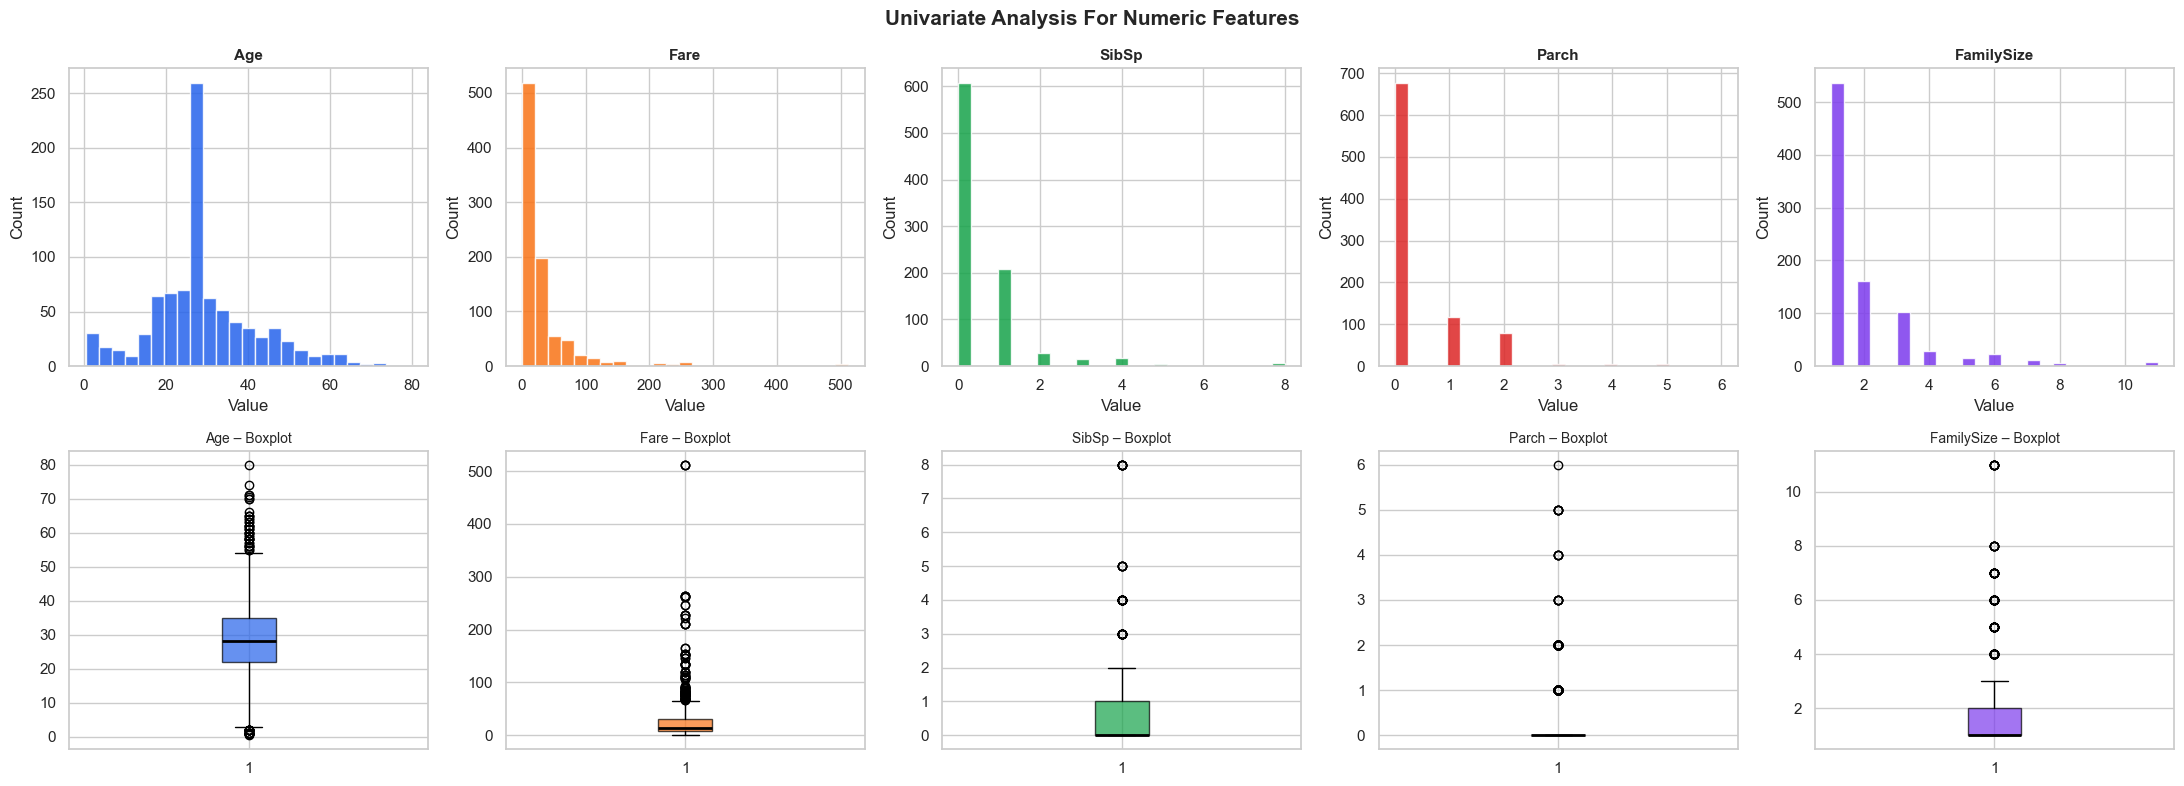

In [14]:
#  Histograms & Boxplots for Numeric Features 
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Univariate Analysis For Numeric Features', fontsize=15, fontweight='bold')
for i, col in enumerate(num_cols):
    ax1, ax2 = axes[0, i], axes[1, i]
    ax1.hist(Titanic[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    ax1.set_title(col, fontsize=11, fontweight='bold')
    ax1.set_xlabel('Value'); ax1.set_ylabel('Count')
    ax2.boxplot(Titanic[col], patch_artist=True,
                boxprops=dict(facecolor=colors[i], alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
    ax2.set_title(f'{col} – Boxplot', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\plot1.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [15]:
# Coefficient of Variation (spread analysis) 
cv_values = {}
for col in num_cols:
    cv_values[col] = (Titanic[col].std() / Titanic[col].mean()) * 100

cv_Titanic = pd.DataFrame.from_dict(cv_values, orient='index', columns=['Coefficient of Variation (%)'])

cv_Titanic

,Coefficient of Variation (%)
Age,44.342625
Fare,154.307253
SibSp,210.846437
Parch,211.234407
FamilySize,84.713704


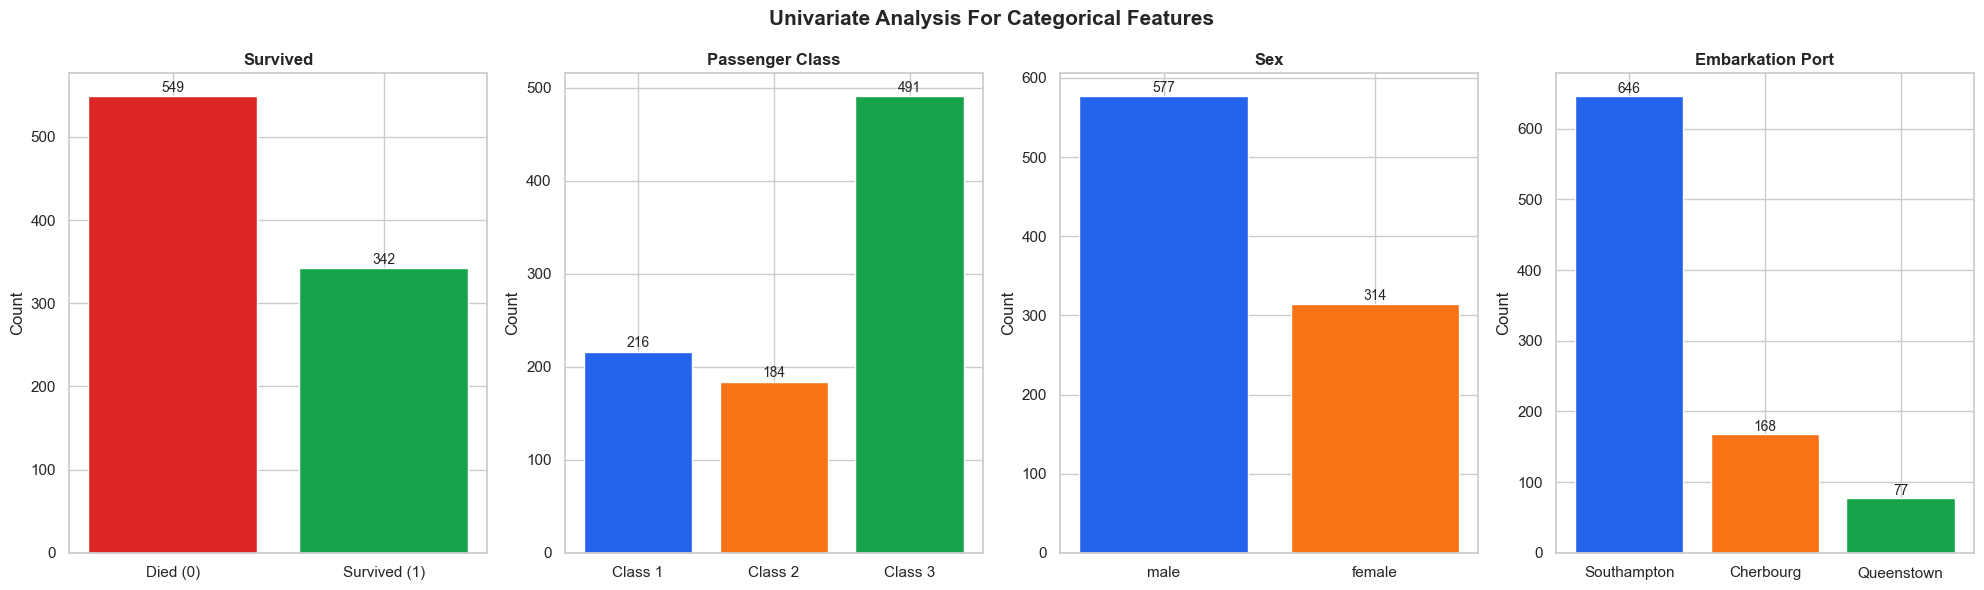

In [16]:
# Categorical Bar Charts 
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Univariate Analysis For Categorical Features', fontsize=15, fontweight='bold')

# Survived
vc = Titanic['Survived'].value_counts()
axes[0].bar(['Died (0)', 'Survived (1)'], [vc.get(0,0), vc.get(1,0)], color=[RED, GREEN], edgecolor='white')
axes[0].set_title('Survived', fontweight='bold')

# Pclass
vc = Titanic['Pclass'].value_counts().sort_index()
axes[1].bar([f'Class {i}' for i in vc.index], vc.values, color=colors[:3], edgecolor='white')
axes[1].set_title('Passenger Class', fontweight='bold')

# Sex
vc = Titanic['Sex'].value_counts()
axes[2].bar(vc.index, vc.values, color=[BLUE, ORANGE], edgecolor='white')
axes[2].set_title('Sex', fontweight='bold')

# Embarked
vc = Titanic['Embarked'].value_counts()
full_names = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
axes[3].bar([full_names.get(x, x) for x in vc.index], vc.values, color=colors[:3], edgecolor='white')
axes[3].set_title('Embarkation Port', fontweight='bold')

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha='center', fontsize=10)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\plot2.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

#Perfoming Bivariate Analysis

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_16060\2637953569.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=['Died','Survived'], medianprops=dict(color='black', linewidth=2))


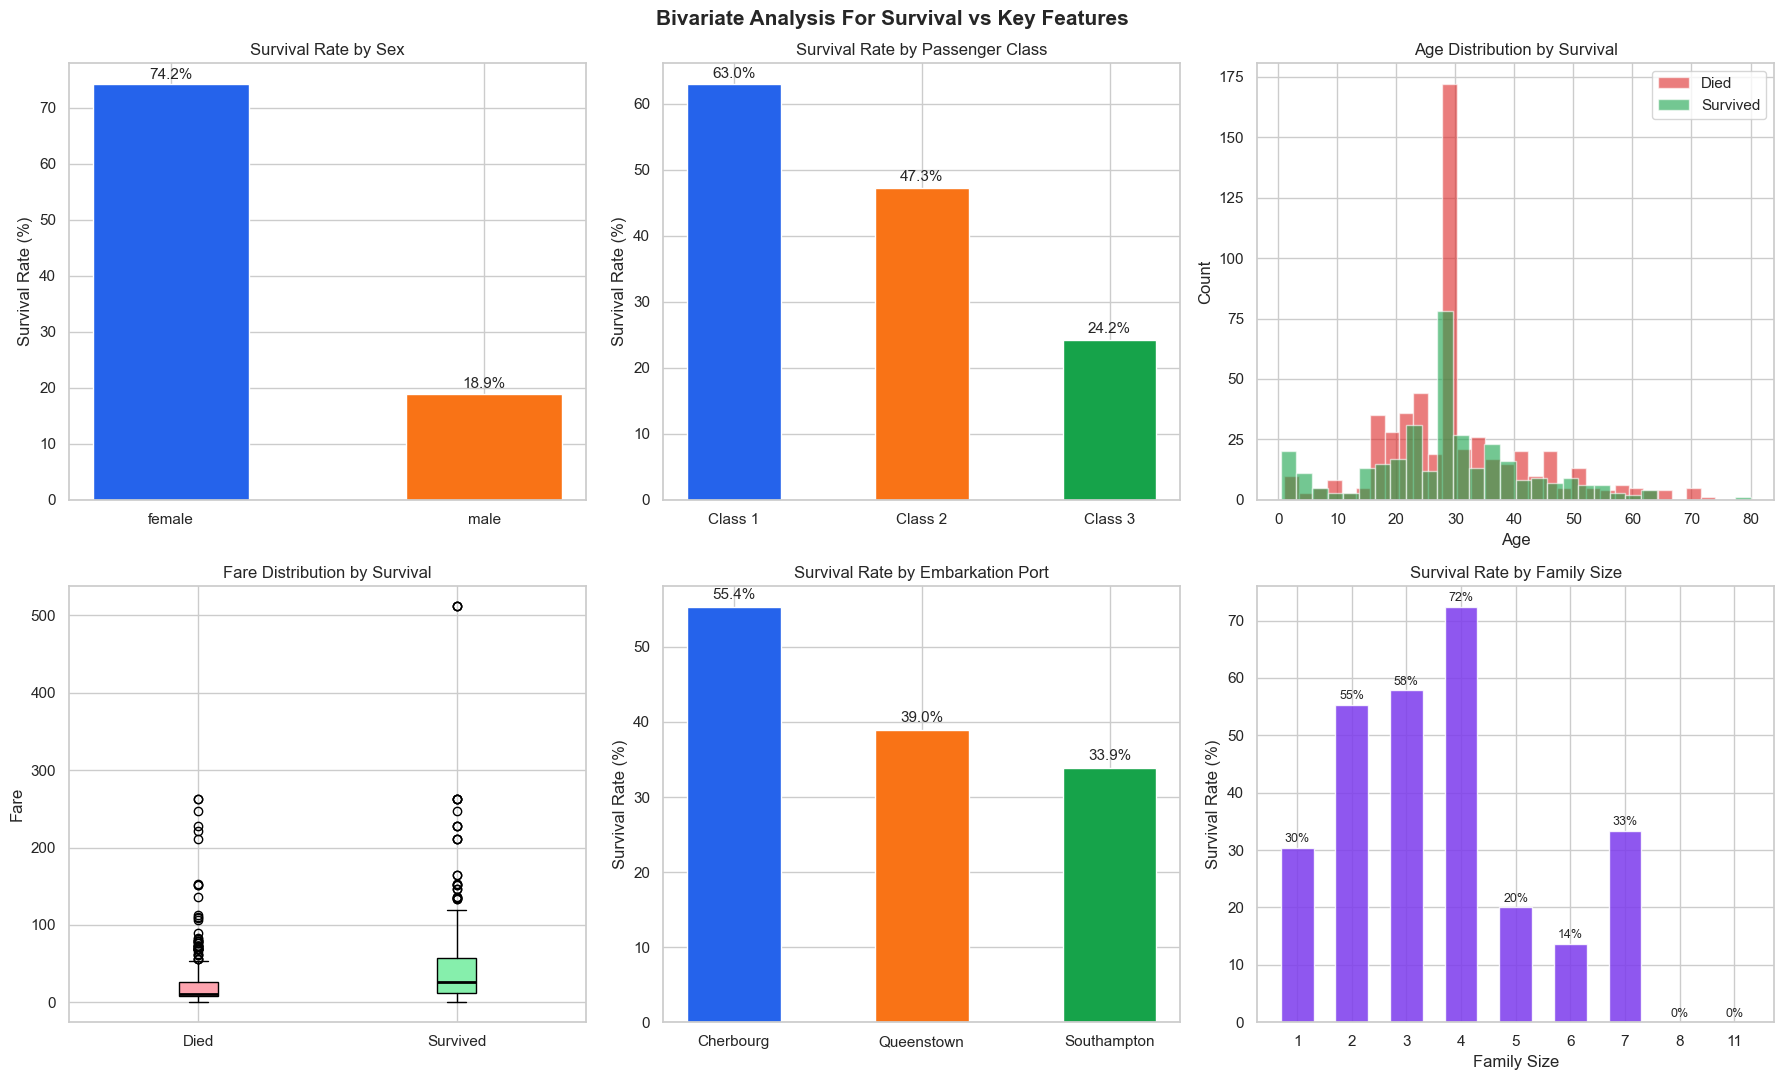

In [17]:
# Survival vs Key Features 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bivariate Analysis For Survival vs Key Features', fontsize=15, fontweight='bold')

# Survival by Sex
ax = axes[0,0]
sex_surv = Titanic.groupby('Sex')['Survived'].mean().reset_index()
bars = ax.bar(sex_surv['Sex'], sex_surv['Survived']*100, color=[BLUE, ORANGE], edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Sex'); ax.set_ylabel('Survival Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}%', ha='center', fontsize=11)

# Survival by Pclass
ax = axes[0,1]
pc_surv = Titanic.groupby('Pclass')['Survived'].mean().reset_index()
bars = ax.bar([f'Class {i}' for i in pc_surv['Pclass']], pc_surv['Survived']*100, color=colors[:3], edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Passenger Class'); ax.set_ylabel('Survival Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}%', ha='center', fontsize=11)

# Age distribution by Survival
ax = axes[0,2]
ax.hist(Titanic[Titanic['Survived']==0]['Age'], bins=30, alpha=0.6, color=RED, label='Died', edgecolor='white')
ax.hist(Titanic[Titanic['Survived']==1]['Age'], bins=30, alpha=0.6, color=GREEN, label='Survived', edgecolor='white')
ax.set_title('Age Distribution by Survival'); ax.set_xlabel('Age'); ax.set_ylabel('Count'); ax.legend()

# Fare by Survival
ax = axes[1,0]
data = [Titanic[Titanic['Survived']==0]['Fare'], Titanic[Titanic['Survived']==1]['Fare']]
bp = ax.boxplot(data, patch_artist=True, labels=['Died','Survived'], medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#FDA4AF'); bp['boxes'][1].set_facecolor('#86EFAC')
ax.set_title('Fare Distribution by Survival'); ax.set_ylabel('Fare')

# Survival by Embarkation
ax = axes[1,1]
emb_surv = Titanic.groupby('Embarked')['Survived'].mean().reset_index()
full_names = {'S':'Southampton','C':'Cherbourg','Q':'Queenstown'}
labels = [full_names.get(x,x) for x in emb_surv['Embarked']]
bars = ax.bar(labels, emb_surv['Survived']*100, color=colors[:3], edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Embarkation Port'); ax.set_ylabel('Survival Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}%', ha='center', fontsize=11)

# Survival by Family Size
ax = axes[1,2]
fam_surv = Titanic.groupby('FamilySize')['Survived'].mean().reset_index()
bars = ax.bar(fam_surv['FamilySize'].astype(str), fam_surv['Survived']*100, color=PURPLE, edgecolor='white', width=0.6, alpha=0.85)
ax.set_title('Survival Rate by Family Size'); ax.set_xlabel('Family Size'); ax.set_ylabel('Survival Rate (%)')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\plot3.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [18]:
# Overall survival rate
overall_survival = pd.DataFrame({
    'Metric': ['Overall Survival Rate (%)'],
    'Value': [round(Titanic['Survived'].mean() * 100, 2)]})

overall_survival

,Metric,Value
0,Overall Survival Rate (%),38.38


#Correlation & Feature Importance

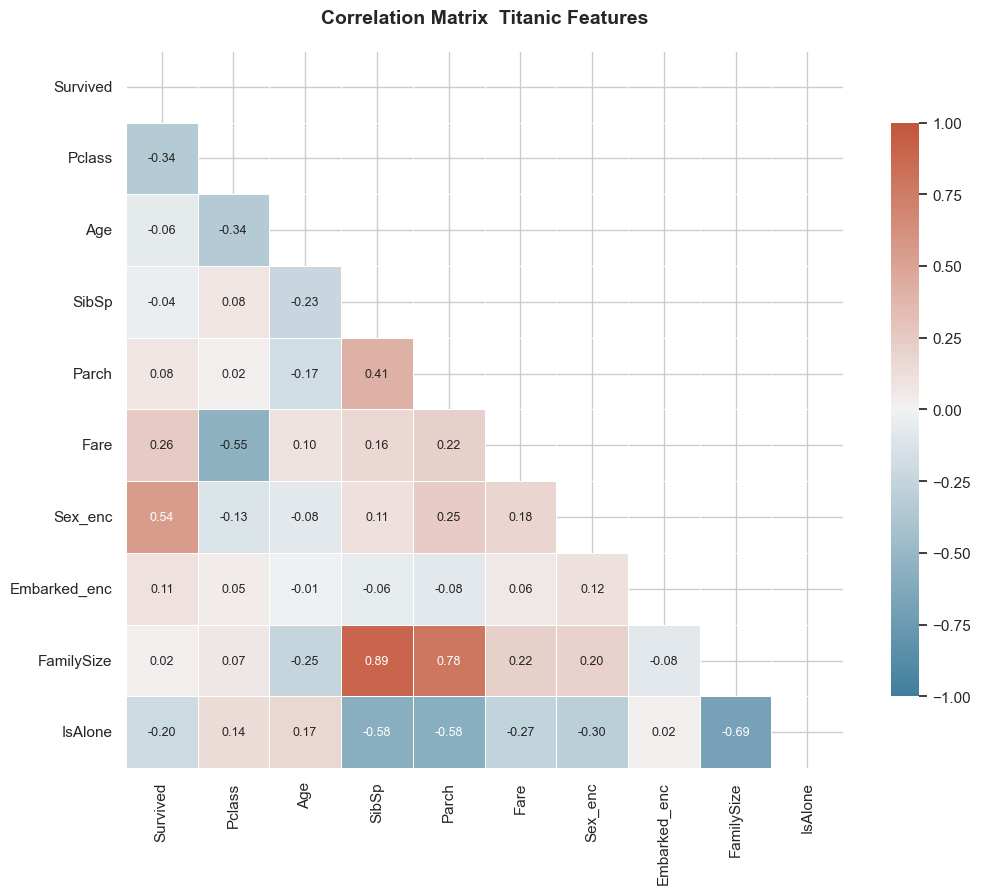

In [19]:
#  Correlation Heatmap 
num_Titanic = Titanic.drop(columns=['Sex', 'Embarked'])
corr = num_Titanic.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': .8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix  Titanic Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\plot4.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

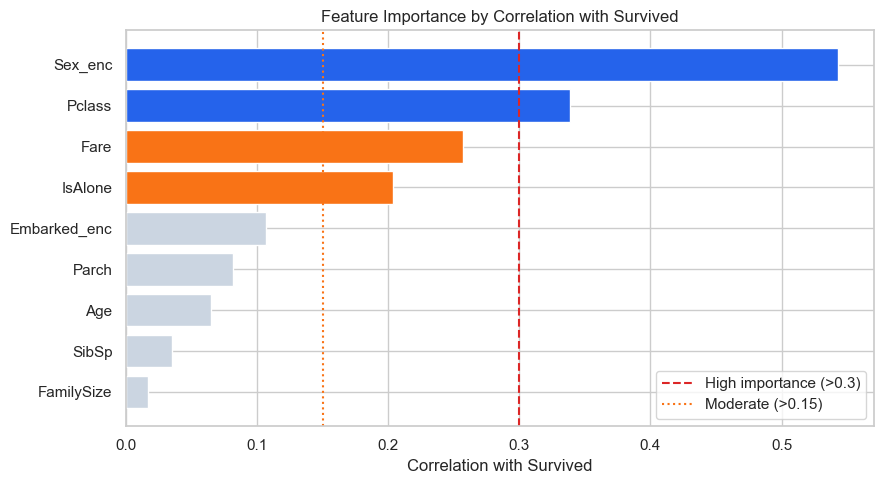

In [20]:
# Feature Importance Ranking 
surv_corr = corr['Survived'].drop('Survived').abs().sort_values(ascending=False)
surv_corr.to_string()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(surv_corr.index[::-1], surv_corr.values[::-1],
               color=[BLUE if v>0.3 else ORANGE if v>0.15 else '#CBD5E1' for v in surv_corr.values[::-1]])
ax.axvline(0.3, color=RED, linestyle='--', linewidth=1.5, label='High importance (>0.3)')
ax.axvline(0.15, color=ORANGE, linestyle=':', linewidth=1.5, label='Moderate (>0.15)')
ax.set_xlabel('Correlation with Survived')
ax.set_title('Feature Importance by Correlation with Survived')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_1_Titanic_project\plot5.png",
            dpi=300,
            bbox_inches='tight')
plt.show()
